### Imports et configuration

In [9]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random

%matplotlib inline

### Chargement des données

In [10]:
def load_metadata_and_counts(dataset_dir: str) -> pd.DataFrame:
    """Lit les fichiers labels YOLO pour compter les insectes par image."""
    base_path = Path(dataset_dir)
    images_dir = base_path / "images"
    labels_dir = base_path / "labels"
    
    data = []
    
    for img_path in images_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
            
        jour = img_path.name[:8]
        label_path = labels_dir / img_path.with_suffix(".txt").name
        
        insect_count = 0
        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                insect_count = len(lines)
                
        data.append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "jour": jour,
            "insect_count": insect_count
        })
        
    return pd.DataFrame(data)

# Chargement depuis le sous-dossier de 'data'
DATASET_DIR = "../data/merged_filtered_dataset" 

print("Analyse des fichiers et comptage des insectes en cours...")
df = load_metadata_and_counts(DATASET_DIR)

# Afficher les 5 premières lignes pour vérifier interactivement
df.head()

Analyse des fichiers et comptage des insectes en cours...


,image_name,image_path,jour,insect_count
0,20221006_09-03-49-024129_raw_jpg.rf.4df65bba71...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
1,20221006_09-11-26-908410_raw_jpg.rf.d17c0ef063...,..\data\merged_filtered_dataset\images\2022100...,20221006,0
2,20221006_09-14-31-840309_raw_jpg.rf.28d2caeab7...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
3,20221006_09-14-34-972005_raw_jpg.rf.5a5d09316b...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
4,20221006_09-14-44-434197_raw_jpg.rf.b0129cf391...,..\data\merged_filtered_dataset\images\2022100...,20221006,1


### Séparation des données (ajustement / test)

In [11]:
# Définition stricte des ensembles d'ajustement et de test
jours_ajustement = ['20221006', '20221007', '20221012', '20221017']
jours_test = ['20221018', '20221019', '20221020']

# Séparation du DataFrame
df_ajustement = df[df['jour'].isin(jours_ajustement)].copy()
df_test = df[df['jour'].isin(jours_test)].copy()

print(f"Images pour l'ajustement (développement) : {len(df_ajustement)}")
print(f"Images pour le test (évaluation finale)  : {len(df_test)}")

Images pour l'ajustement (développement) : 702
Images pour le test (évaluation finale)  : 399


### Fonction de comptage du nombre d'insecte sur un masque

In [12]:
def count_insects_from_mask(mask, min_area=5, max_area=700, max_detections=8):
    """
    Extrait le nombre d'insectes. La tâche sur le masque peut faire au minimum 5 pixels et au maximum 700. Si le nombre dépasse max_detections, 
    renvoie une erreur et annule les détections.
    """
    _, binary = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    valid_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area <= area <= max_area:
            x, y, w, h = cv2.boundingRect(cnt)
            valid_boxes.append((x, y, w, h))
            
    nb_pred = len(valid_boxes)
    is_error = False
    
    # Le garde-fou : on considère l'image comme illisible/aberrante
    if nb_pred > max_detections:
        is_error = True
        nb_pred = 0
        valid_boxes = [] # On efface les boîtes aberrantes
        
    return nb_pred, valid_boxes, is_error

### Résultats sur le jeu de test : performances de comptage de l'approche MOG2



RÉSULTATS DU TEST : JOUR 20221018 (148 images)
Garde-Fou   : 142 images validées | 6 images rejetées (4.1%)
Accuracy    : 49.3 % d'images avec prédiction parfaite
MAE         : 0.58 erreur en moyenne (moyenne réelle: 1.98 insectes/image)
WAPE        : 29.2 % d'erreur par rapport au volume total d'insectes
Pire erreur : Différence de 3 insectes sur l'image 20221018_09-01-14-040594_raw_jpg.rf.5c7612122f765d5ac77071df0afa2272.jpg


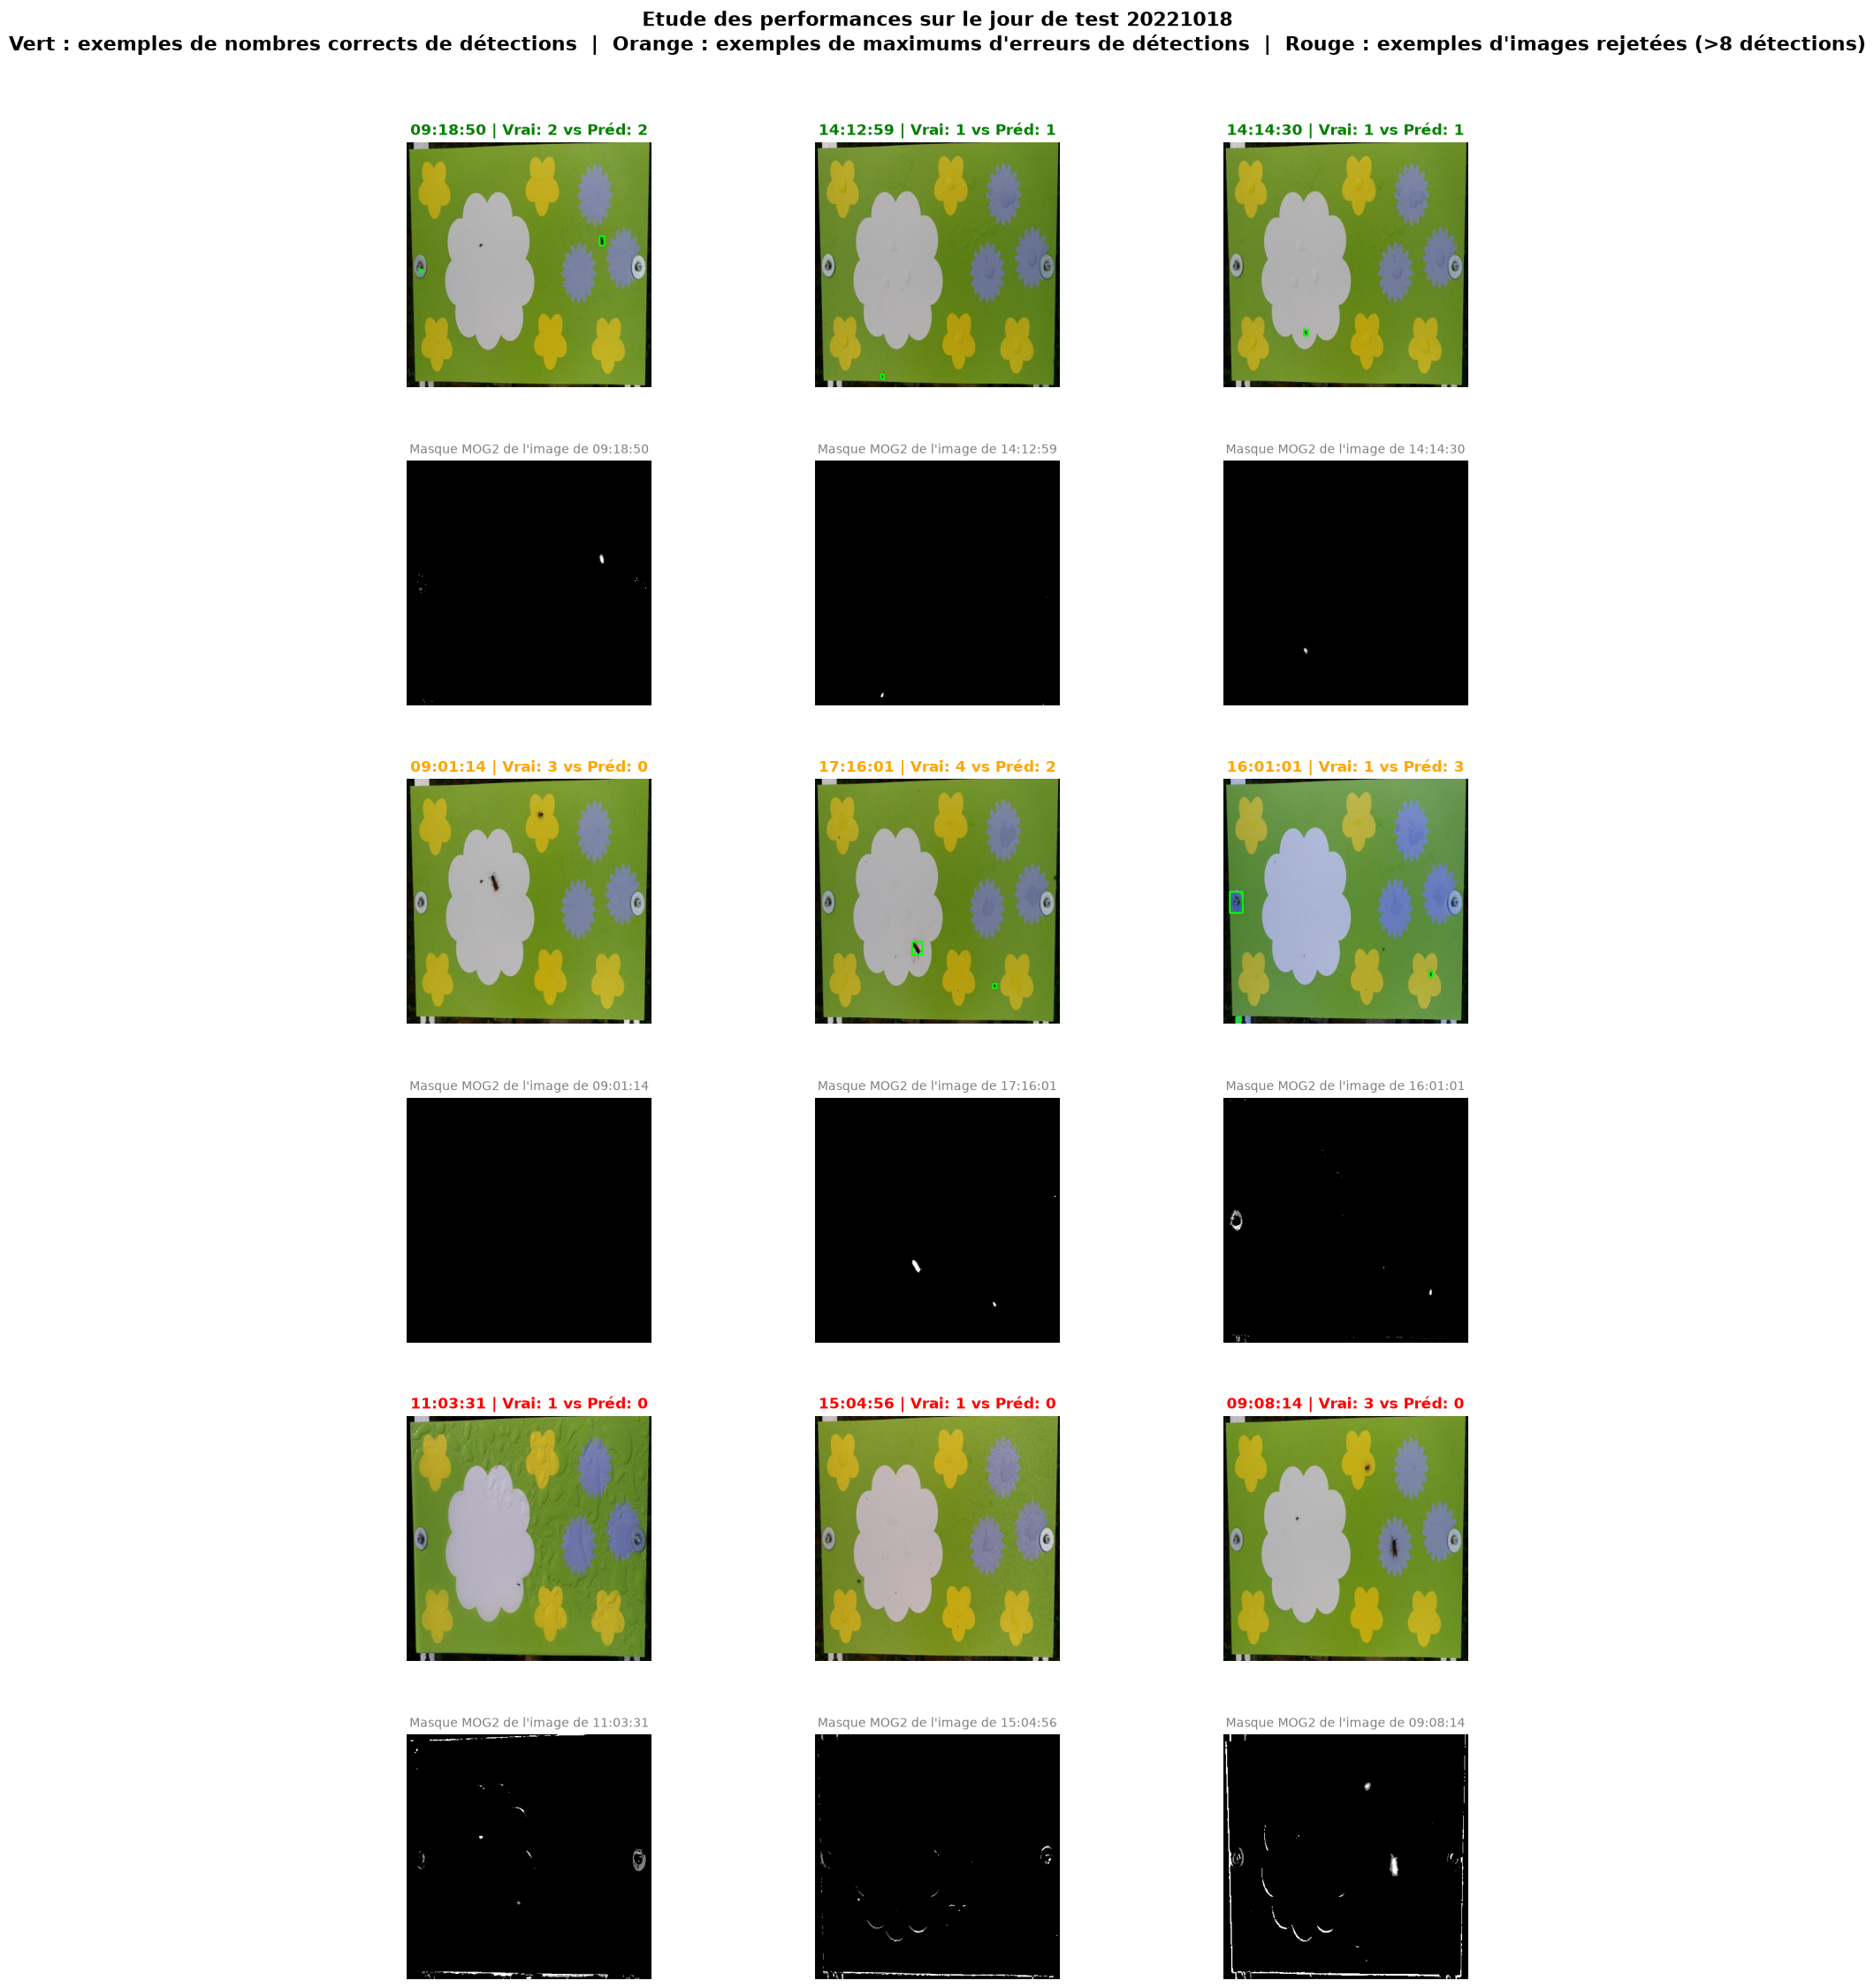



RÉSULTATS DU TEST : JOUR 20221019 (185 images)
Garde-Fou   : 177 images validées | 8 images rejetées (4.3%)
Accuracy    : 46.9 % d'images avec prédiction parfaite
MAE         : 0.80 erreur en moyenne (moyenne réelle: 2.12 insectes/image)
WAPE        : 37.6 % d'erreur par rapport au volume total d'insectes
Pire erreur : Différence de 7 insectes sur l'image 20221019_16-12-36-177406_raw_jpg.rf.6d83bf617f8f87a8b70ba4edbb36ca62.jpg


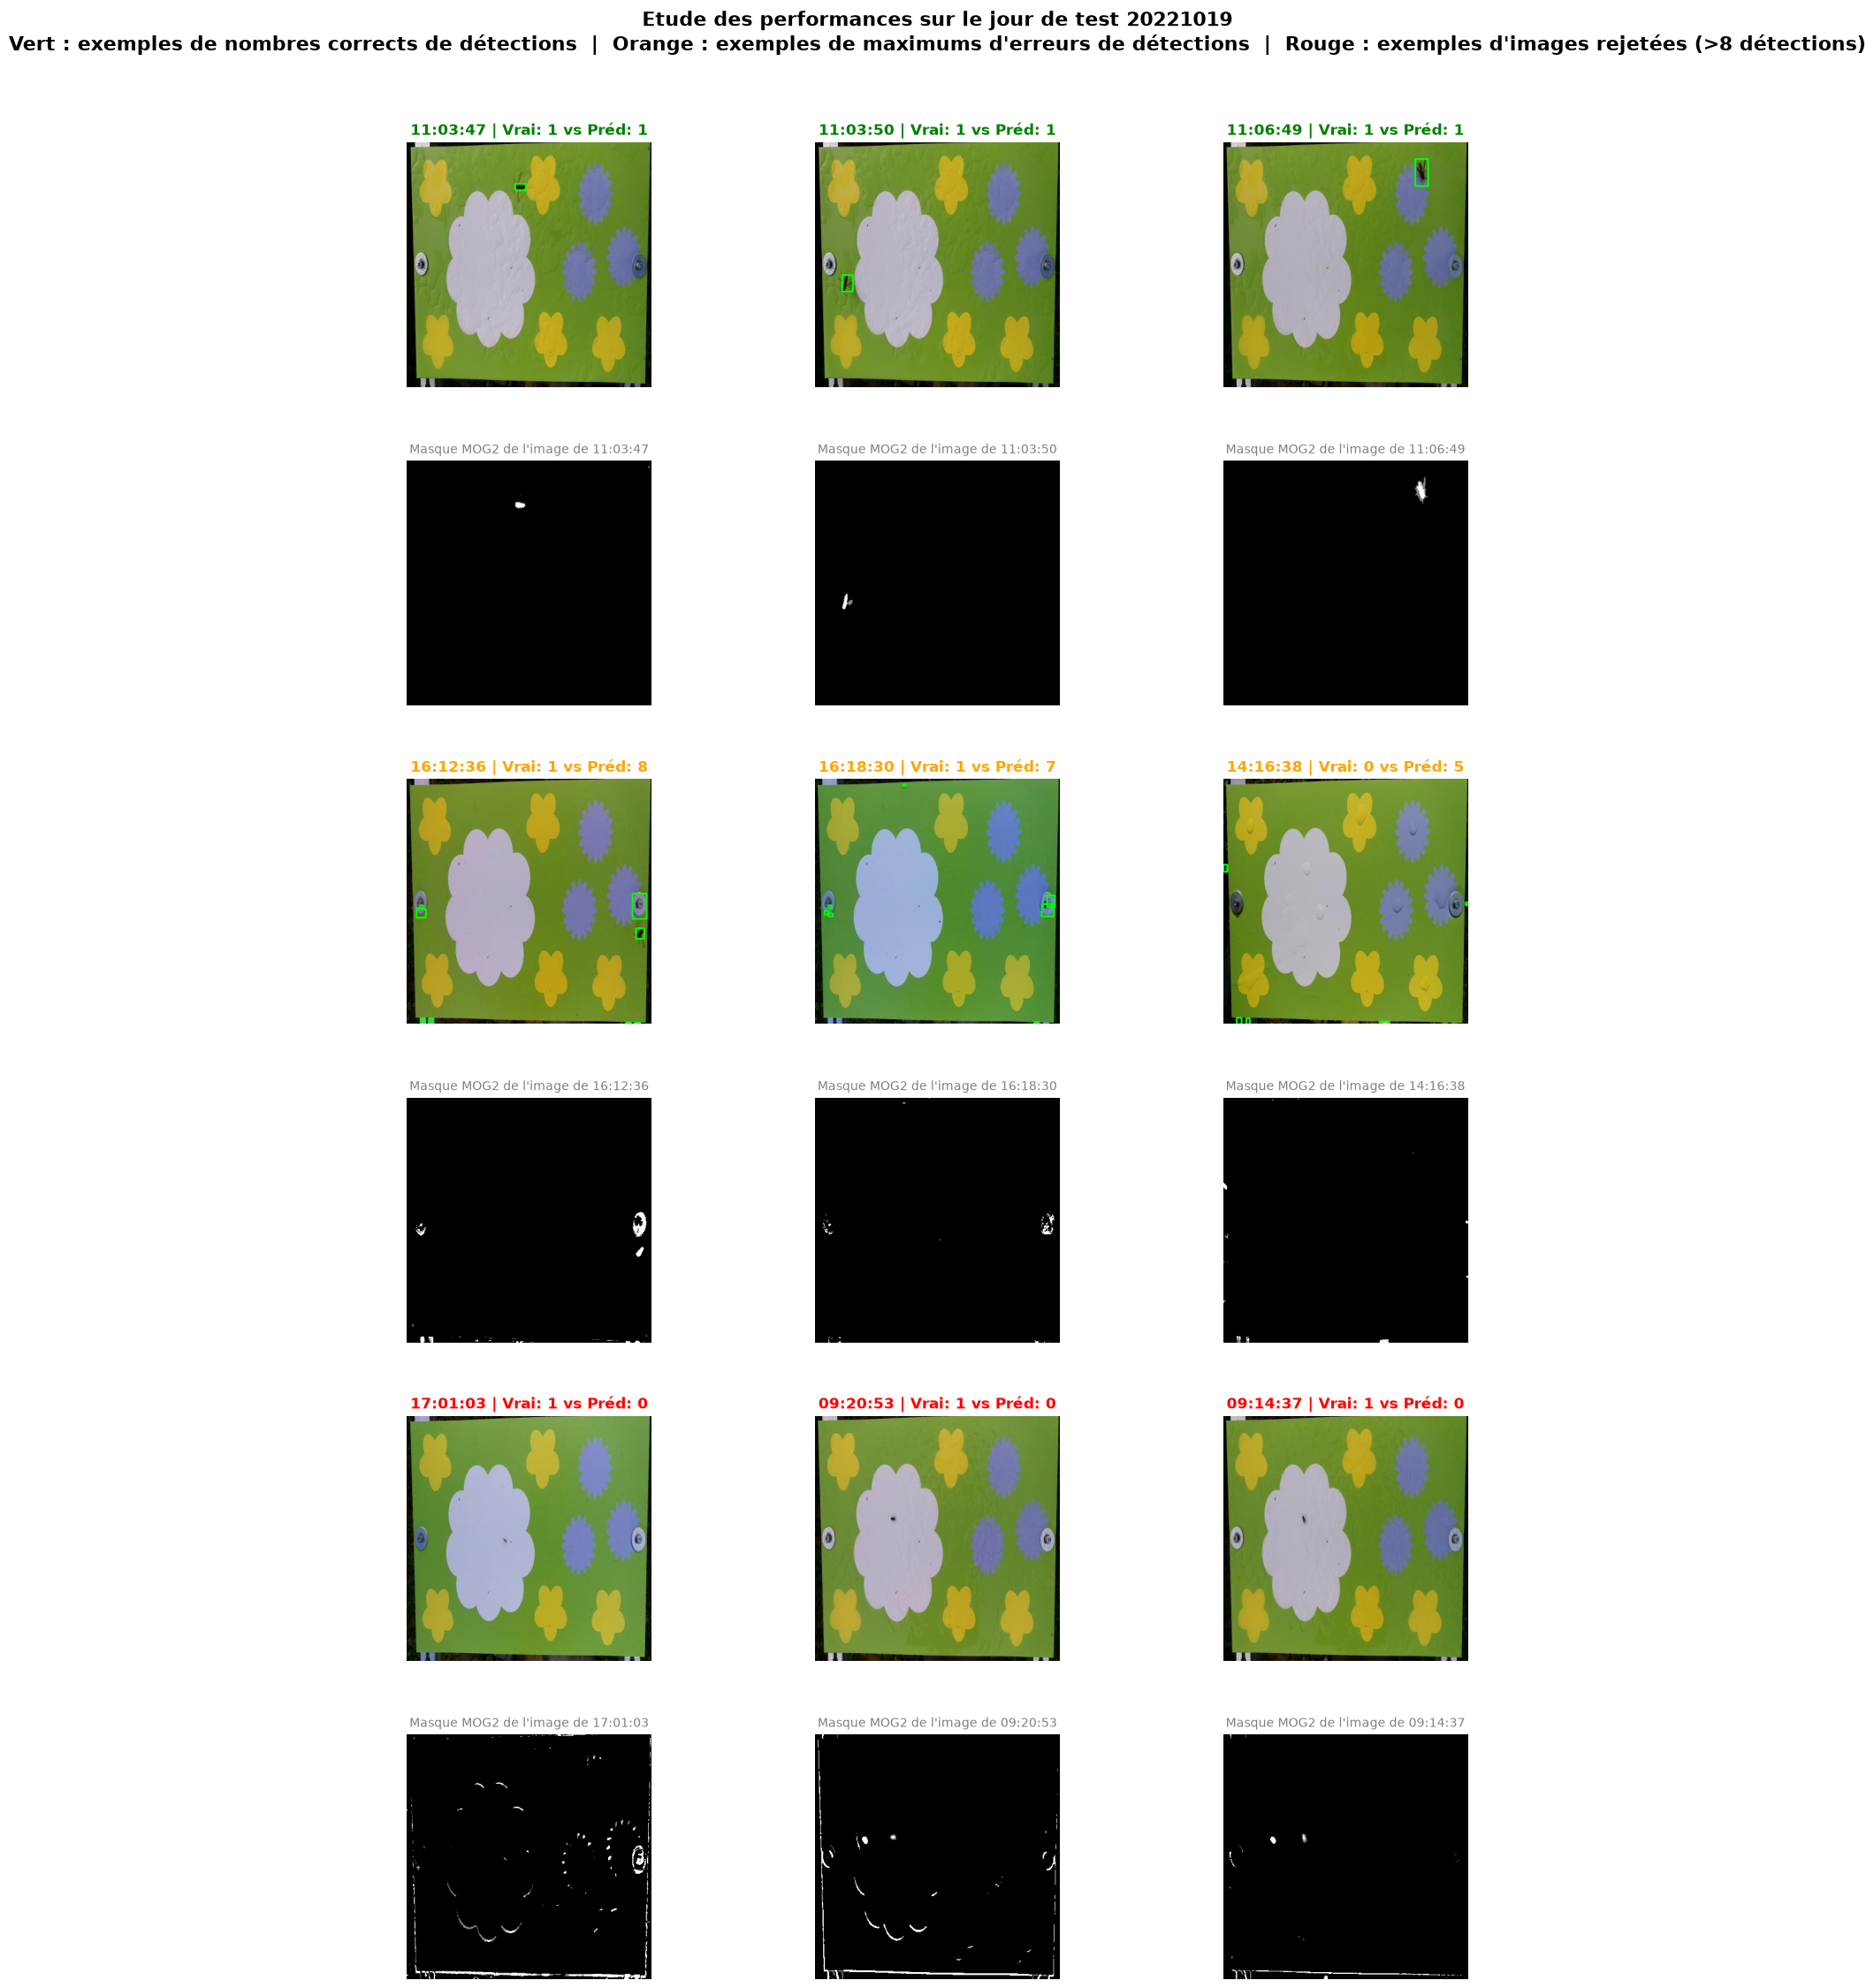



RÉSULTATS DU TEST : JOUR 20221020 (66 images)
Garde-Fou   : 60 images validées | 6 images rejetées (9.1%)
Accuracy    : 73.3 % d'images avec prédiction parfaite
MAE         : 0.47 erreur en moyenne (moyenne réelle: 1.17 insectes/image)
WAPE        : 40.0 % d'erreur par rapport au volume total d'insectes
Pire erreur : Différence de 4 insectes sur l'image 20221020_11-26-30-828257_raw_jpg.rf.3c9714afc7020c1a31ea70bd37f60198.jpg


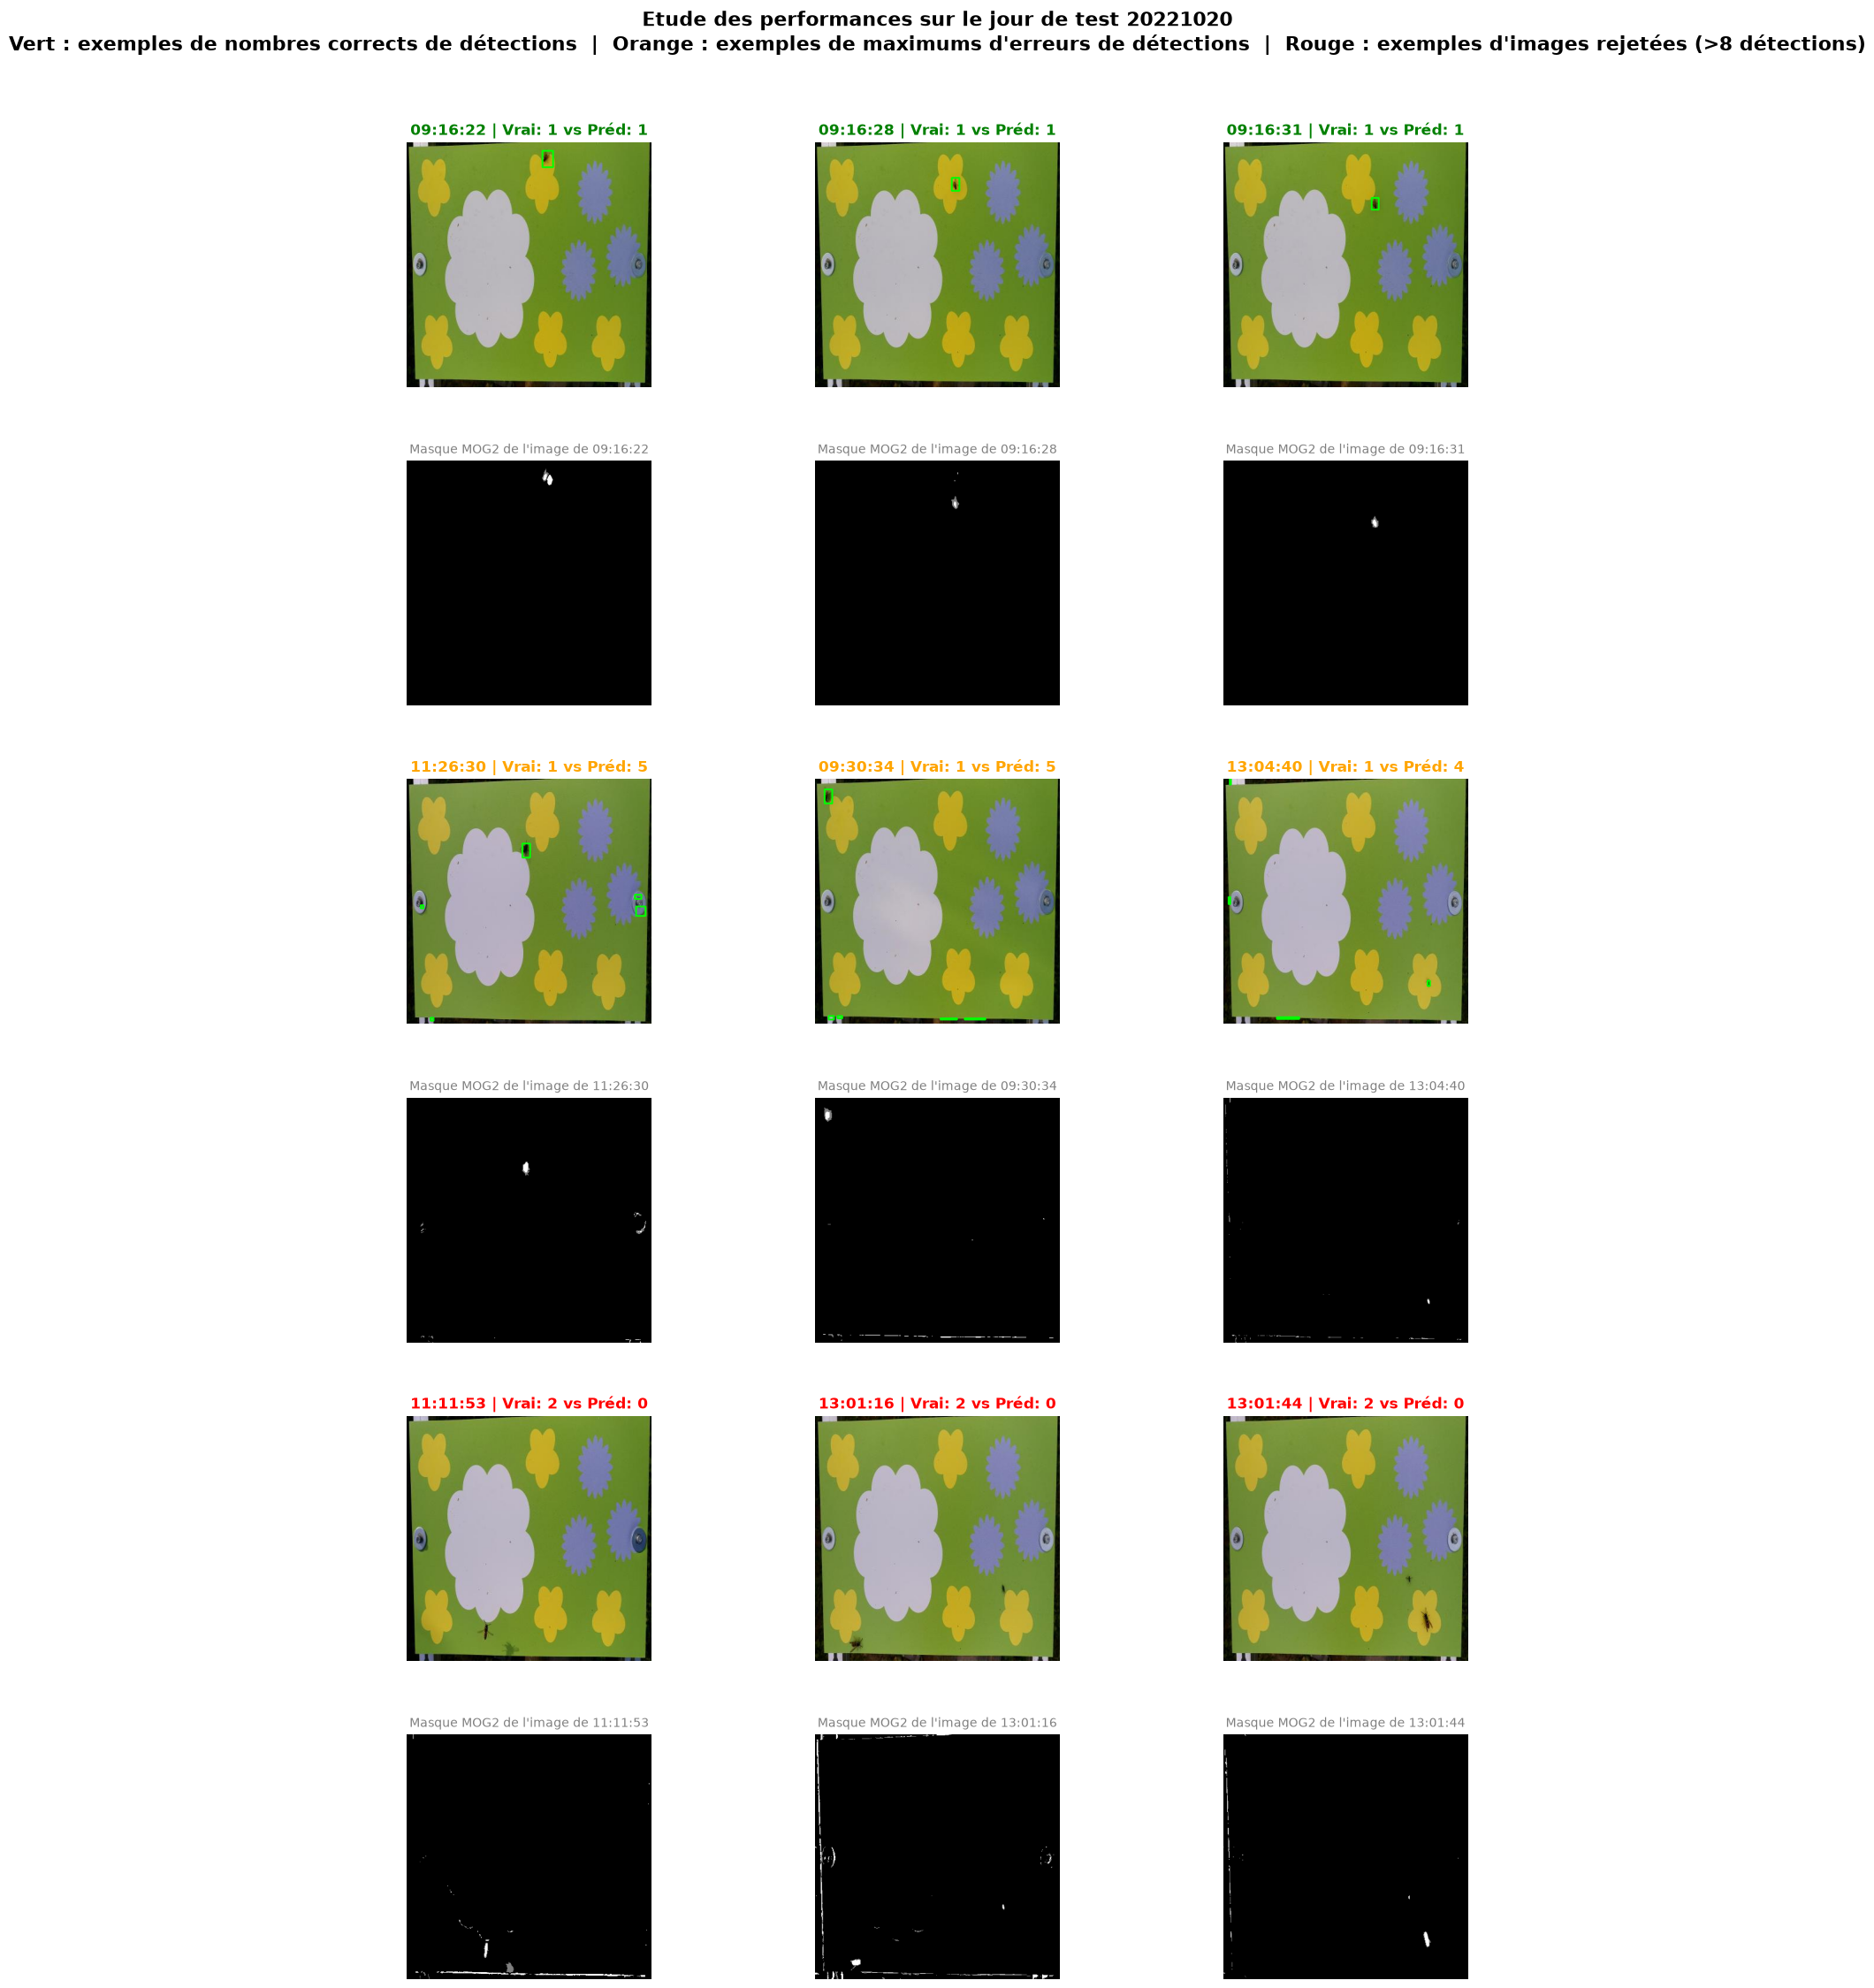



************************************************************
BILAN GLOBAL SUR LE JEU DE TEST (399 images au total)
************************************************************
Garde-Fou   : 379 validées | 20 rejetées (5.0%)
Accuracy    : 52.0 % d'images avec prédiction parfaite
MAE globale : 0.66 erreur en moyenne (moyenne réelle globale: 1.92)
WAPE global : 34.6 % d'erreur totale


In [13]:
# Paramètres figés issus du GridSearch
VAR_THRESH_OPT = 100  
LR_OPT = 0.05        

def afficher_galerie_evaluation(top_3, flop_3, rejets_3, day):
    """Génère une grille 6x3 pour inspecter visuellement les prédictions et leurs masques."""
    # On agrandit la figure pour accommoder les 6 lignes
    fig, axes = plt.subplots(6, 3, figsize=(15, 22)) 
    
    titre_principal = (f"Etude des performances sur le jour de test {day}\n"
                       f"Vert : exemples de nombres corrects de détections  |  "
                       f"Orange : exemples de maximums d'erreurs de détections  |  "
                       f"Rouge : exemples d'images rejetées (>8 détections)")
    fig.suptitle(titre_principal, fontsize=16, y=1.02, fontweight='bold')
    
    # Structure : (Titre, données, couleur, index_de_la_ligne_image)
    categories = [
        ("TOP 3", top_3, 'green', 0),    # Les images à la ligne 0, les masques à la 1
        ("FLOP 3", flop_3, 'orange', 2), # Les images à la ligne 2, les masques à la 3
        ("REJETS", rejets_3, 'red', 4)   # Les images à la ligne 4, les masques à la 5
    ]
    
    for titre_cat, liste_images, couleur, row_img in categories:
        row_mask = row_img + 1 # Le masque est toujours sur la ligne juste en dessous
        
        for col_idx in range(3):
            ax_img = axes[row_img, col_idx]
            ax_mask = axes[row_mask, col_idx]
            
            if col_idx < len(liste_images):
                res = liste_images[col_idx]
                
                # --- Affichage de l'image ---
                img = cv2.imread(res['image_path'])
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                for (x, y, w, h) in res['boxes']:
                    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
                    
                ax_img.imshow(img_rgb)
                heure = res['image_name'][9:17].replace('-', ':')
                titre_image = f"{heure} | Vrai: {res['nb_vrai']} vs Préd: {res['nb_pred']}"
                ax_img.set_title(titre_image, fontsize=12, color=couleur, fontweight='bold')
                
                # --- Affichage du masque ---
                ax_mask.imshow(res['mask'], cmap='gray')
                ax_mask.set_title(f"Masque MOG2 de l'image de {heure}", fontsize=10, color='gray')
                
            # Retirer les axes de toute façon (même pour les cases vides)
            ax_img.axis('off')
            ax_mask.axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3) # Ajoute un peu d'espace vertical entre les rangées
    plt.show()

# Initialisation des compteurs globaux pour le bilan
global_N_total = 0
global_N_valide = 0
global_N_rejets = 0
global_total_vrai = 0
global_total_error = 0
global_images_parfaites = 0
global_erreurs = []

# Exécution sur les jours de Test
jours_test = ['20221018', '20221019', '20221020']

for day in jours_test:
    df_day = df_test[df_test['jour'] == day].sort_values("image_name")
    backSub = cv2.createBackgroundSubtractorMOG2(history=15, varThreshold=VAR_THRESH_OPT, detectShadows=True)
    
    resultats_valides = []
    rejets = []
    
    # Phase de Prédiction
    for _, row in df_day.iterrows():
        img = cv2.imread(row['image_path'])
        if img is None: continue
            
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        mask_raw = backSub.apply(img_blur, learningRate=LR_OPT)
        
        nb_pred, boxes, is_error = count_insects_from_mask(mask_raw, min_area=5, max_area=700, max_detections=8)
        nb_vrai = row['insect_count']
        
        dictionnaire_resultat = {
            'image_name': row['image_name'],
            'image_path': row['image_path'],
            'nb_vrai': nb_vrai,
            'nb_pred': nb_pred,
            'error': abs(nb_pred - nb_vrai),
            'boxes': boxes,
            'mask': mask_raw
        }
        
        if is_error:
            rejets.append(dictionnaire_resultat)
        else:
            resultats_valides.append(dictionnaire_resultat)
            
    # Calcul des Métriques Journalières
    N_total = len(df_day)
    N_valide = len(resultats_valides)
    N_rejets = len(rejets)
    
    # Mise à jour des compteurs globaux
    global_N_total += N_total
    global_N_valide += N_valide
    global_N_rejets += N_rejets
    
    print(f"\n\n{'='*60}")
    print(f"RÉSULTATS DU TEST : JOUR {day} ({N_total} images)")
    print(f"{'='*60}")
    
    if N_valide > 0:
        resultats_valides.sort(key=lambda x: x['error'])
        
        total_vrai = sum(r['nb_vrai'] for r in resultats_valides)
        total_error = sum(r['error'] for r in resultats_valides)
        images_parfaites = sum(1 for r in resultats_valides if r['error'] == 0)
        
        # Mise à jour des compteurs globaux (suite)
        global_total_vrai += total_vrai
        global_total_error += total_error
        global_images_parfaites += images_parfaites
        global_erreurs.extend([r['error'] for r in resultats_valides])
        
        moyenne_vrai = total_vrai / N_valide
        mae = total_error / N_valide
        wape = (total_error / total_vrai * 100) if total_vrai > 0 else 0
        accuracy = (images_parfaites / N_valide) * 100
        pire_cas = resultats_valides[-1] 
        
        print(f"Garde-Fou   : {N_valide} images validées | {N_rejets} images rejetées ({(N_rejets/N_total)*100:.1f}%)")
        print(f"Accuracy    : {accuracy:.1f} % d'images avec prédiction parfaite")
        print(f"MAE         : {mae:.2f} erreur en moyenne (moyenne réelle: {moyenne_vrai:.2f} insectes/image)")
        print(f"WAPE        : {wape:.1f} % d'erreur par rapport au volume total d'insectes")
        print(f"Pire erreur : Différence de {pire_cas['error']} insectes sur l'image {pire_cas['image_name']}")
        
        # 3. Extraction visuelle
        top_3 = [r for r in resultats_valides if r['error'] == 0][:3]
        flop_3 = resultats_valides[-3:][::-1]
        rejets_3 = random.sample(rejets, min(3, N_rejets)) if N_rejets > 0 else []
        
        afficher_galerie_evaluation(top_3, flop_3, rejets_3, day)
    else:
        print("Toutes les images de cette journée ont été rejetées par le plafond (>8 détections).")

# --- 4. Bilan Global sur les 3 jours ---
print(f"\n\n{'*'*60}")
print(f"BILAN GLOBAL SUR LE JEU DE TEST ({global_N_total} images au total)")
print(f"{'*'*60}")

if global_N_valide > 0:
    global_moyenne_vrai = global_total_vrai / global_N_valide
    global_mae = global_total_error / global_N_valide
    global_wape = (global_total_error / global_total_vrai * 100) if global_total_vrai > 0 else 0
    global_accuracy = (global_images_parfaites / global_N_valide) * 100
    
    print(f"Garde-Fou   : {global_N_valide} validées | {global_N_rejets} rejetées ({(global_N_rejets/global_N_total)*100:.1f}%)")
    print(f"Accuracy    : {global_accuracy:.1f} % d'images avec prédiction parfaite")
    print(f"MAE globale : {global_mae:.2f} erreur en moyenne (moyenne réelle globale: {global_moyenne_vrai:.2f})")
    print(f"WAPE global : {global_wape:.1f} % d'erreur totale")
else:
    print("Aucune donnée valide pour générer des statistiques globales.")

### Resultats sur le jeu de test : étude des Bounding Boxes prédites / réelles

In [14]:
def parse_yolo_labels(label_path, img_width, img_height):
    """Convertit les coordonnées YOLO normalisées en Bounding Boxes absolues (x, y, w, h)."""
    true_boxes = []
    if Path(label_path).exists():
        with open(label_path, 'r') as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
            for line in lines:
                parts = line.split()
                if len(parts) >= 5:
                    # YOLO format : class_id x_center y_center width height (normalisés 0-1)
                    x_c, y_c, w_norm, h_norm = map(float, parts[1:5])
                    
                    w = int(w_norm * img_width)
                    h = int(h_norm * img_height)
                    x = int((x_c * img_width) - (w / 2))
                    y = int((y_c * img_height) - (h / 2))
                    true_boxes.append((x, y, w, h))
    return true_boxes

def compute_io_min(box1, box2):
    """Calcule l'Intersection sur Minimum (IoM) entre deux Bounding Boxes."""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    # Coordonnées de l'intersection
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)
    
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    if inter_area == 0:
        return 0.0
        
    # Aires respectives
    box1_area = w1 * h1
    box2_area = w2 * h2
    
    # Au lieu de l'Union, on prend l'aire minimale
    min_area = min(box1_area, box2_area)
    
    return inter_area / min_area

def evaluate_detections(pred_boxes, true_boxes, overlap_threshold=0.5):
    """
    Associe les prédictions aux vrais insectes en utilisant l'IoM.
    Un seuil de 0.5 exige que la moitié de la plus petite boîte soit recouverte.
    """
    matched_true = set()
    true_positives = 0
    
    for p_box in pred_boxes:
        best_iom = 0
        best_t_idx = -1
        
        for t_idx, t_box in enumerate(true_boxes):
            if t_idx in matched_true:
                continue
                
            iom = compute_io_min(p_box, t_box)
            if iom > best_iom:
                best_iom = iom
                best_t_idx = t_idx
                
        if best_iom >= overlap_threshold:
            true_positives += 1
            matched_true.add(best_t_idx)
            
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(true_boxes) - true_positives
    
    return true_positives, false_positives, false_negatives

# Exécution de l'évaluation spatiale
LABELS_DIR = Path("../data/merged_filtered_dataset/labels") 

jours_test = ['20221018', '20221019', '20221020']

global_tp, global_fp, global_fn = 0, 0, 0

for day in jours_test:
    df_day = df_test[df_test['jour'] == day].sort_values("image_name")
    backSub = cv2.createBackgroundSubtractorMOG2(history=15, varThreshold=VAR_THRESH_OPT, detectShadows=True)
    
    day_tp, day_fp, day_fn = 0, 0, 0
    
    for _, row in df_day.iterrows():
        img_path = Path(row['image_path'])
        img = cv2.imread(str(img_path))
        if img is None: continue
        
        h_img, w_img = img.shape[:2]
        
        # Parsing YOLO
        label_name = img_path.with_suffix(".txt").name
        label_file = LABELS_DIR / label_name
        true_boxes = parse_yolo_labels(label_file, w_img, h_img)
        
        # Prédiction OpenCV
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        mask_raw = backSub.apply(img_blur, learningRate=LR_OPT)
        _, pred_boxes, is_error = count_insects_from_mask(mask_raw, min_area=5, max_area=700, max_detections=8)
        
        # Si le garde-fou a rejeté l'image, on compte 0 prédiction (tout est faux négatif)
        if is_error:
            pred_boxes = []
            
        # Association et Métriques
        tp, fp, fn = evaluate_detections(pred_boxes, true_boxes, overlap_threshold=0.5)
        day_tp += tp
        day_fp += fp
        day_fn += fn
        
    global_tp += day_tp
    global_fp += day_fp
    global_fn += day_fn
    
    precision = (day_tp / (day_tp + day_fp)) * 100 if (day_tp + day_fp) > 0 else 0
    recall = (day_tp / (day_tp + day_fn)) * 100 if (day_tp + day_fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{'='*55}")
    print(f"ÉVALUATION SPATIALE : JOUR {day}")
    print(f"{'='*55}")
    print(f"Vrais positifs (Insectes bien détectés) : {day_tp}")
    print(f"Faux positifs (Bruit/ombres détectés)    : {day_fp}")
    print(f"Faux négatifs (Insectes ratés)           : {day_fn}")
    print(f"-"*55)
    print(f"Précision (qualité des boîtes tracées)   : {precision:.1f} %")
    print(f"Rappel    (exhaustivité de détection)    : {recall:.1f} %")
    print(f"F1-Score  (équilibre global)             : {f1_score:.1f} %")

# Bilan spatial global
g_precision = (global_tp / (global_tp + global_fp)) * 100 if (global_tp + global_fp) > 0 else 0
g_recall = (global_tp / (global_tp + global_fn)) * 100 if (global_tp + global_fn) > 0 else 0
g_f1_score = (2 * g_precision * g_recall) / (g_precision + g_recall) if (g_precision + g_recall) > 0 else 0

print(f"\n\n{'*'*55}")
print(f"BILAN SPATIAL GLOBAL SUR LE JEU DE TEST")
print(f"{'*'*55}")
print(f"Précision globale : {g_precision:.1f} %")
print(f"Rappel global     : {g_recall:.1f} %")
print(f"F1-Score global   : {g_f1_score:.1f} %")


ÉVALUATION SPATIALE : JOUR 20221018
Vrais positifs (Insectes bien détectés) : 199
Faux positifs (Bruit/ombres détectés)    : 10
Faux négatifs (Insectes ratés)           : 93
-------------------------------------------------------
Précision (qualité des boîtes tracées)   : 95.2 %
Rappel    (exhaustivité de détection)    : 68.2 %
F1-Score  (équilibre global)             : 79.4 %

ÉVALUATION SPATIALE : JOUR 20221019
Vrais positifs (Insectes bien détectés) : 292
Faux positifs (Bruit/ombres détectés)    : 88
Faux négatifs (Insectes ratés)           : 91
-------------------------------------------------------
Précision (qualité des boîtes tracées)   : 76.8 %
Rappel    (exhaustivité de détection)    : 76.2 %
F1-Score  (équilibre global)             : 76.5 %

ÉVALUATION SPATIALE : JOUR 20221020
Vrais positifs (Insectes bien détectés) : 68
Faux positifs (Bruit/ombres détectés)    : 28
Faux négatifs (Insectes ratés)           : 11
-------------------------------------------------------
Précisio

### Etude de l'Io-Min

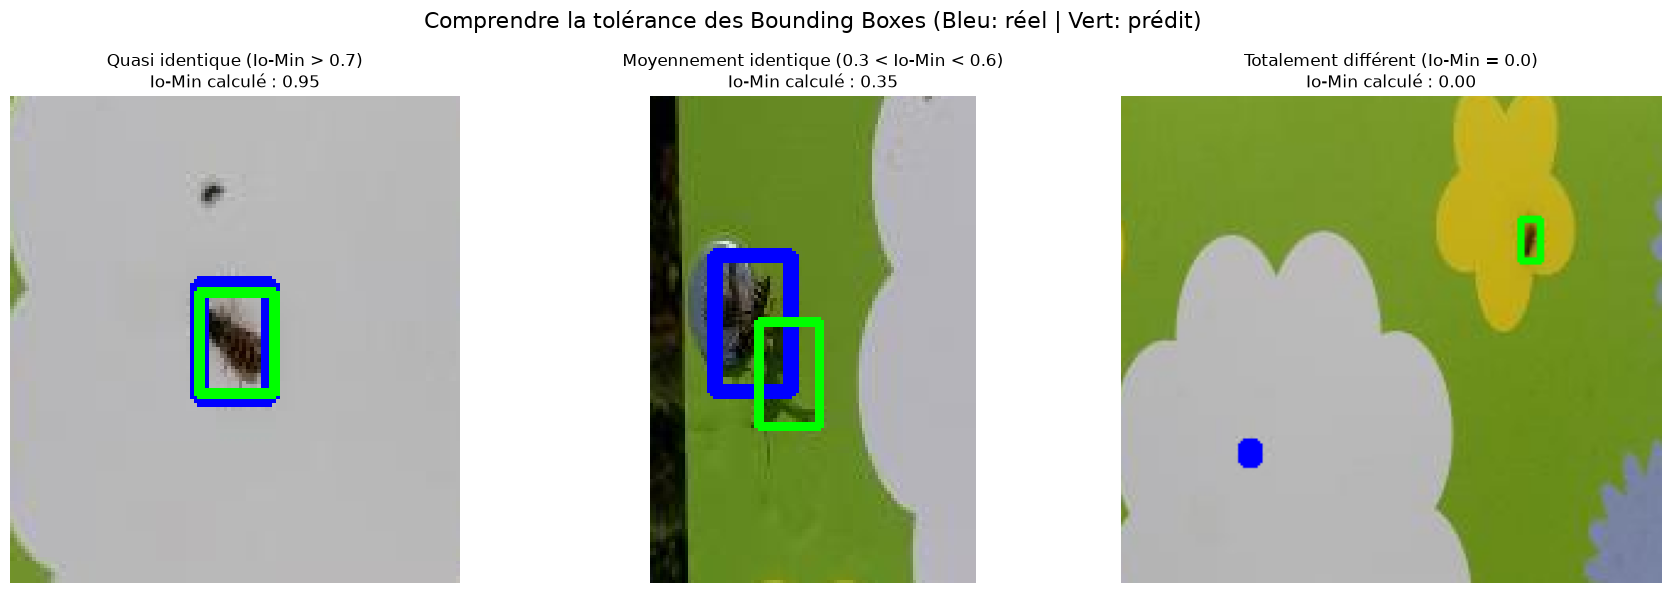

In [15]:
def trouver_exemples_iom(df, labels_dir, backSub, lr_opt):
    """Fonction qui parcourt le jeu de test pour dénicher des cas spécifiques d'Io-Min."""
    exemples = {'parfait': None, 'moyen': None, 'echec': None}
    
    for _, row in df.iterrows():
        # Si on a trouvé nos 3 exemples, on arrête la recherche
        if all(exemples.values()):
            break
            
        img_path = Path(row['image_path'])
        img = cv2.imread(str(img_path))
        if img is None: continue
        
        # Vraies boîtes
        label_file = labels_dir / img_path.with_suffix(".txt").name
        true_boxes = parse_yolo_labels(label_file, img.shape[1], img.shape[0])
        if not true_boxes: continue
            
        # Boîtes prédites
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        mask = backSub.apply(img_blur, learningRate=lr_opt)
        _, pred_boxes, _ = count_insects_from_mask(mask, min_area=5, max_area=700, max_detections=8)
        
        if not pred_boxes: continue

        # On teste l'IoU de la première prédiction avec la première vraie boîte
        iou = compute_io_min(pred_boxes[0], true_boxes[0])
        
        res_dict = {'img': img.copy(), 't_box': true_boxes[0], 'p_box': pred_boxes[0], 'iou': iou}
        
        if iou > 0.7 and exemples['parfait'] is None:
            exemples['parfait'] = res_dict
        elif 0.3 <= iou <= 0.6 and exemples['moyen'] is None:
            exemples['moyen'] = res_dict
        elif iou == 0.0 and exemples['echec'] is None:
            # S'assurer qu'il y a bien une vraie boîte et une prédiction, mais qui ne se touchent pas du tout
            exemples['echec'] = res_dict
            
    return exemples

# Exécution et affichage
# On réinitialise l'algo pour une recherche neutre
backSub_visu = cv2.createBackgroundSubtractorMOG2(history=15, varThreshold=VAR_THRESH_OPT, detectShadows=True)
exemples_trouves = trouver_exemples_iom(df_test, LABELS_DIR, backSub_visu, LR_OPT)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comprendre la tolérance des Bounding Boxes (Bleu: réel | Vert: prédit)", fontsize=16)

titres = [
    ("Quasi identique (Io-Min > 0.7)", 'parfait'),
    ("Moyennement identique (0.3 < Io-Min < 0.6)", 'moyen'),
    ("Totalement différent (Io-Min = 0.0)", 'echec')
]

for idx, (titre, cle) in enumerate(titres):
    ax = axes[idx]
    data = exemples_trouves[cle]
    
    if data is not None:
        img_draw = cv2.cvtColor(data['img'], cv2.COLOR_BGR2RGB)
        
        # Vraie boîte en bleu
        x, y, w, h = data['t_box']
        cv2.rectangle(img_draw, (x, y), (x+w, y+h), (0, 0, 255), 3) # OpenCV utilise RGB ici car on a converti
        
        # Boîte prédite en vert
        xp, yp, wp, hp = data['p_box']
        cv2.rectangle(img_draw, (xp, yp), (xp+wp, yp+hp), (0, 255, 0), 2)
        
        # Zoomer sur la zone d'intérêt pour bien voir la différence
        marge = 50
        x_min = max(0, min(x, xp) - marge)
        y_min = max(0, min(y, yp) - marge)
        x_max = min(img_draw.shape[1], max(x+w, xp+wp) + marge)
        y_max = min(img_draw.shape[0], max(y+h, yp+hp) + marge)
        
        ax.imshow(img_draw[y_min:y_max, x_min:x_max])
        ax.set_title(f"{titre}\nIo-Min calculé : {data['iou']:.2f}")
    else:
        ax.set_title(f"{titre}\n(Aucun exemple trouvé dans ce run)")
        
    ax.axis('off')

plt.tight_layout()
plt.show()

### Performance à priori de l'algorithme (quand l'image n'est pas rejetée)

FIABILITÉ OPÉRATIONNELLE DE L'ALGORITHME :
---------------------------------------------
Probabilité de (0 erreur)  : 52.0 %
Probabilité de (≤ 1 erreur): 90.5 %
---------------------------------------------


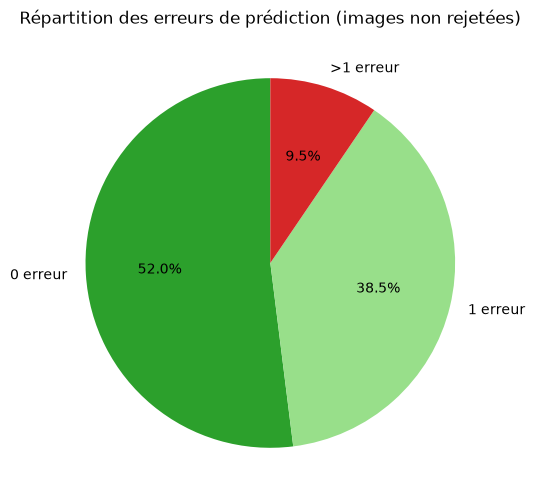

In [18]:
# Probabilité de succès à ±1 insecte 
if global_erreurs:
    # On compte combien d'images ont une erreur de 0 ou 1
    succes_elargi = sum(1 for err in global_erreurs if err <= 1)
    
    # Calcul de la probabilité en pourcentage
    proba_0_ou_1 = (succes_elargi / len(global_erreurs)) * 100
    
    # On peut aussi calculer la proba d'avoir exactement 0 erreur
    proba_0 = (global_images_parfaites / len(global_erreurs)) * 100

    print(f"FIABILITÉ OPÉRATIONNELLE DE L'ALGORITHME :")
    print(f"-" * 45)
    print(f"Probabilité de (0 erreur)  : {proba_0:.1f} %")
    print(f"Probabilité de (≤ 1 erreur): {proba_0_ou_1:.1f} %")
    print(f"-" * 45)
    
    # diagramme circulaire
    import matplotlib.pyplot as plt
    labels = ['0 erreur', '1 erreur', '>1 erreur']
    erreurs_1 = sum(1 for err in global_erreurs if err == 1)
    echecs = len(global_erreurs) - global_images_parfaites - erreurs_1
    
    tailles = [global_images_parfaites, erreurs_1, echecs]
    couleurs = ['#2ca02c', '#98df8a', '#d62728']
    
    plt.figure(figsize=(6, 6))
    plt.pie(tailles, labels=labels, colors=couleurs, autopct='%1.1f%%', startangle=90)
    plt.title("Répartition des erreurs de prédiction (images non rejetées)")
    plt.show()
else:
    print("Aucune donnée valide pour calculer les probabilités.")